In [1]:
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

## Load Data

In [2]:
train_df = pd.read_parquet("train.parquet")
val_df   = pd.read_parquet("val.parquet")
test_df  = pd.read_parquet("test.parquet")

print(
    f"Train rows: {len(train_df)} | "
    f"Val rows: {len(val_df)} | "
    f"Test rows: {len(test_df)}"
)


Train rows: 52259860 | Val rows: 853720 | Test rows: 853720


## Feature List

In [3]:
FEATURES = [
    # calendar
    "dow", "weekofyear", "month",

    # lags
    "lag_7", "lag_14", "lag_28",

    # rolling means
    "rmean_7", "rmean_14", "rmean_28",

    # events / SNAP (if present)
    "snap_CA", "snap_TX", "snap_WI"
]


## Convert to Numpy

In [4]:
def prepare_xgb_arrays(df, features):
    X = df[features].to_numpy(dtype=np.float32, copy=False)
    y = df["sales"].to_numpy(dtype=np.float32, copy=False)
    return X, y


## Evaluation Function

In [5]:
def evaluate(y_true, y_pred, name):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    denom = np.maximum(y_true, 1.0)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100

    print(f"\n{name}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAPE : {mape:.2f}%")

    return mae, rmse, mape


## WRMSSE computation

In [6]:
def compute_wrmsse(train_df, eval_df, pred_col,
                   target_col="sales", id_col="id"):

    weights = train_df.groupby(id_col)[target_col].sum()
    weights = weights / weights.sum()

    scale = train_df.groupby(id_col)[target_col].apply(
        lambda x: np.mean(np.diff(x.values) ** 2) if len(x) > 1 else np.nan
    )

    rmsse_vals = {}

    for sid, g in eval_df.groupby(id_col):
        s = scale.get(sid, np.nan)
        if not np.isfinite(s) or s == 0:
            continue

        mse = np.mean((g[target_col].values - g[pred_col].values) ** 2)
        rmsse_vals[sid] = np.sqrt(mse / s)

    rmsse_vals = pd.Series(rmsse_vals)
    weights = weights.reindex(rmsse_vals.index).fillna(0.0)

    return float((weights * rmsse_vals).sum())


## Unified evaluation

In [7]:
def evaluate_with_wrmsse(train_df, eval_df, y_true, y_pred, pred_col, name):
    mae, rmse, mape = evaluate(y_true, y_pred, name)

    eval_df = eval_df.copy()
    eval_df[pred_col] = y_pred

    wrmsse = compute_wrmsse(train_df, eval_df, pred_col)
    print(f"WRMSSE: {wrmsse:.4f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "WRMSSE": wrmsse
    }


## Prepare XGBoost Metrics

In [8]:
X_train, y_train = prepare_xgb_arrays(train_df, FEATURES)
X_val, y_val     = prepare_xgb_arrays(val_df, FEATURES)

dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val, label=y_val)

del X_train, X_val
gc.collect()


0

## XGBoost Parameters

In [9]:
xgb_params = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "max_depth": 7,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42
}


## Train Model

In [10]:
xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=3000,
    evals=[(dval, "val")],
    early_stopping_rounds=100,
    verbose_eval=200
)


[0]	val-rmse:3.35222
[200]	val-rmse:2.09260
[400]	val-rmse:2.08324
[600]	val-rmse:2.07808
[800]	val-rmse:2.07592
[1000]	val-rmse:2.07511
[1171]	val-rmse:2.07568


## Validation evaluation

In [11]:
val_pred = xgb_model.predict(dval)

xgb_val_results = evaluate_with_wrmsse(
    train_df=train_df,
    eval_df=val_df,
    y_true=y_val,
    y_pred=val_pred,
    pred_col="xgb_pred",
    name="XGBoost (Validation)"
)



XGBoost (Validation)
MAE  : 0.9063
RMSE : 2.0757
MAPE : 53.08%
WRMSSE: 0.6979


## Test Evaluation

In [12]:
X_test, y_test = prepare_xgb_arrays(test_df, FEATURES)
dtest = xgb.DMatrix(X_test)

test_pred = xgb_model.predict(dtest)

xgb_test_results = evaluate_with_wrmsse(
    train_df=train_df,        
    eval_df=test_df,
    y_true=y_test,
    y_pred=test_pred,
    pred_col="xgb_pred",
    name="XGBoost (Test)"
)



XGBoost (Test)
MAE  : 0.9386
RMSE : 2.2747
MAPE : 54.73%
WRMSSE: 0.7554


## Final results 

In [13]:
final_results = pd.DataFrame([
    xgb_val_results,
    xgb_test_results
])

final_results


,Model,MAE,RMSE,MAPE,WRMSSE
0,XGBoost (Validation),0.906330,2.075682,53.077990,0.697853
1,XGBoost (Test),0.938619,2.274732,54.729396,0.755392


In [14]:
xgb_val_plot_df = val_df.copy()
xgb_val_plot_df["xgb_pred"] = val_pred


## Actual vs prediction

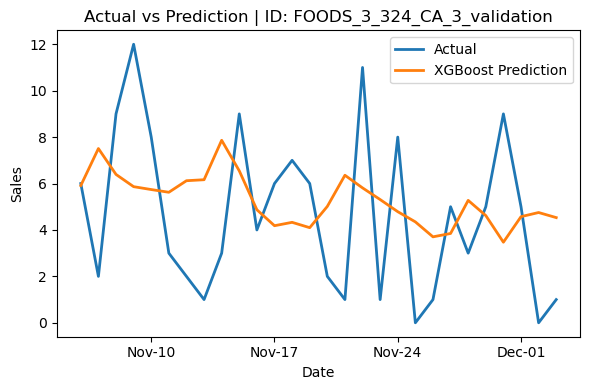

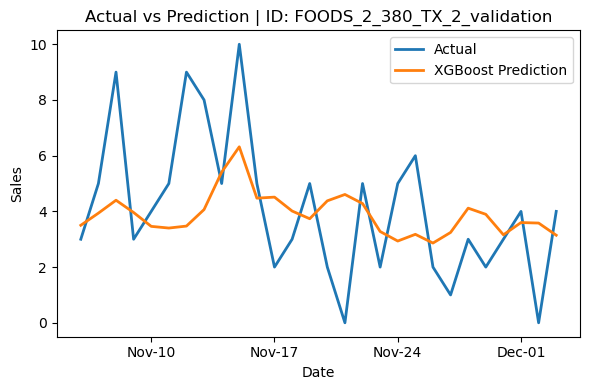

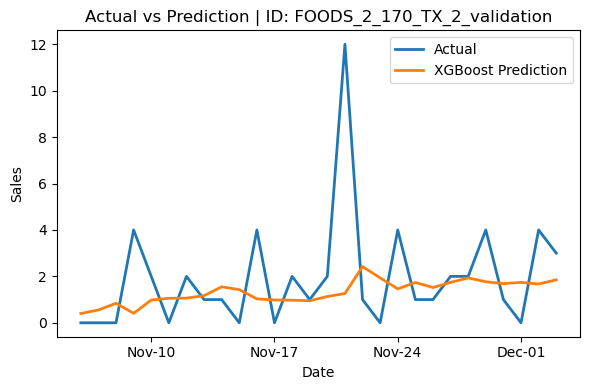

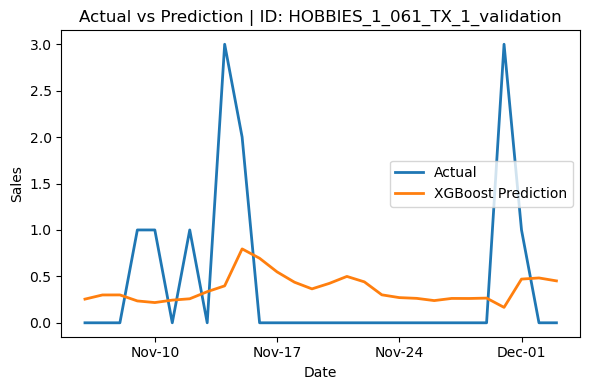

In [19]:
valid_ids = (
    xgb_val_plot_df.groupby("id")["sales"]
    .sum()
    .loc[lambda x: x > 0]
    .index
)

np.random.seed(42)
selected_ids = np.random.choice(valid_ids, size=4, replace=False)


def plot_actual_vs_pred(series_id):
    df_plot = xgb_val_plot_df[xgb_val_plot_df["id"] == series_id]

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(df_plot["date"], df_plot["sales"], label="Actual", linewidth=2)
    ax.plot(df_plot["date"], df_plot["xgb_pred"], label="XGBoost Prediction", linewidth=2)

    ax.set_title(f"Actual vs Prediction | ID: {series_id}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Sales")
    ax.legend()

    # Clean date formatting
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()


for sid in selected_ids:
    plot_actual_vs_pred(sid)

## Average residuals over time 

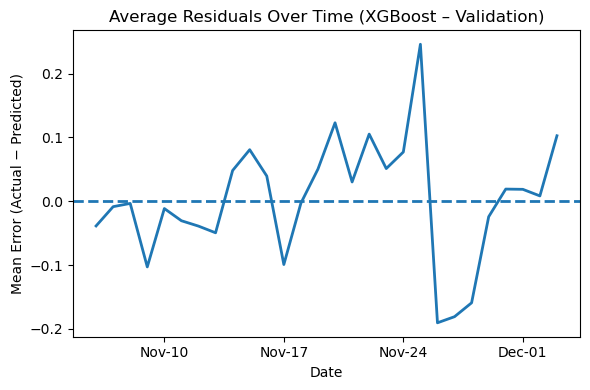

In [20]:
xgb_val_plot_df["residual"] = (
    xgb_val_plot_df["sales"] - xgb_val_plot_df["xgb_pred"]
)

daily_residuals = (
    xgb_val_plot_df.groupby("date")["residual"].mean()
)

plt.figure(figsize=(6, 4))
plt.plot(daily_residuals.index, daily_residuals.values, linewidth=2)
plt.axhline(0, linestyle="--", linewidth=2)

plt.title("Average Residuals Over Time (XGBoost – Validation)")
plt.xlabel("Date")
plt.ylabel("Mean Error (Actual − Predicted)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))

plt.tight_layout()
plt.show()

## Residual distribution

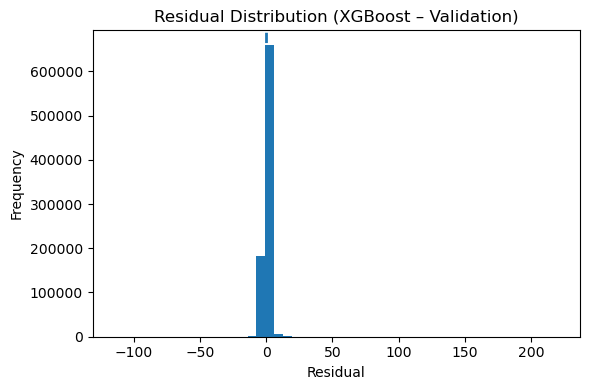

In [18]:
plt.figure(figsize=(6, 4))
plt.hist(xgb_val_plot_df["residual"], bins=50)
plt.axvline(0, linestyle="--", linewidth=2)

plt.title("Residual Distribution (XGBoost – Validation)")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()